## Modeling
In this notebook I test out different models and how they work on the dataset.

In [1]:
# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..')) # This is to ensure the path gets found correctly

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm

In [2]:
# load in the data
X_train, X_val, X_test, y_train, y_val, y_test = dp.load_split_data('dataset1')

In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
0,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
2,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
3,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
4,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


In [4]:
y_train.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Plug_future, dtype: float64

### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.968     1.000     0.984      1531
         1.0      0.000     0.000     0.000        50

    accuracy                          0.968      1581
   macro avg      0.484     0.500     0.492      1581
weighted avg      0.938     0.968     0.953      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [6]:
model = dm.train_and_evaluate_rf(X_train, X_val, y_train, y_val)

Validation accuracy: 0.747


### Check feature importance / redundancy

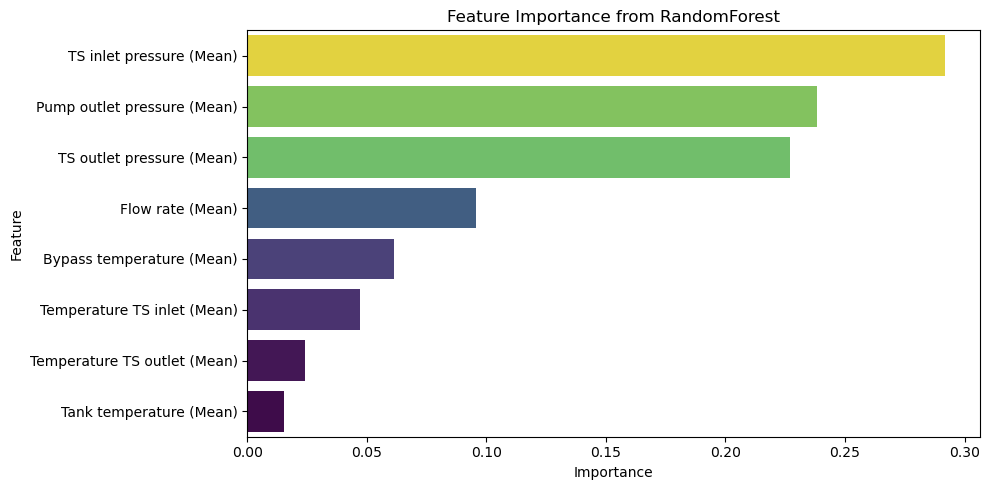

In [7]:
feat_imp = dv.plot_feature_importance(model, X_train)

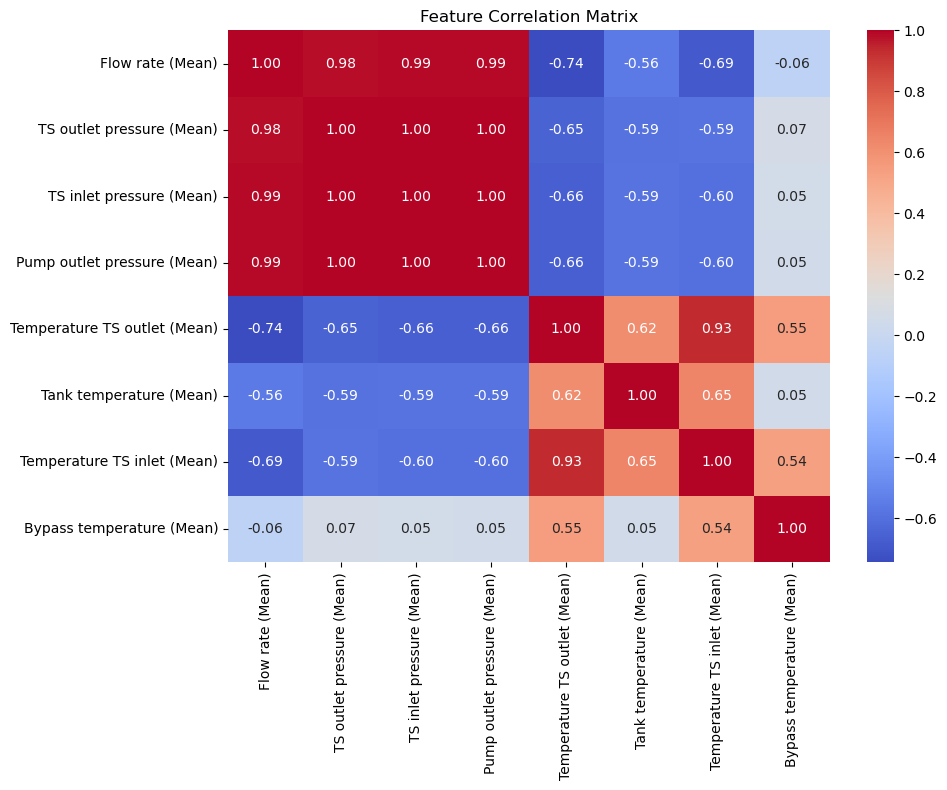

In [8]:
dv.plot_correlation_matrix(X_train)

In [9]:
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_low_importance_features(X_train, X_val, X_test, feat_imp, threshold=0.01)
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_highly_correlated_features(X_train_reduced, X_val_reduced, X_test_reduced, threshold=0.9)

In [10]:
X_train_reduced.head(5)

,Flow rate (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Bypass temperature (Mean)
0,2006.990755,-6.231957,-6.344172,25.589479
1,2006.802163,-6.287087,-6.373047,25.573727
2,2006.990755,-6.245083,-6.338922,25.592105
3,2005.764905,-6.255584,-6.370422,25.584228
4,2005.576313,-6.247708,-6.375672,25.589479


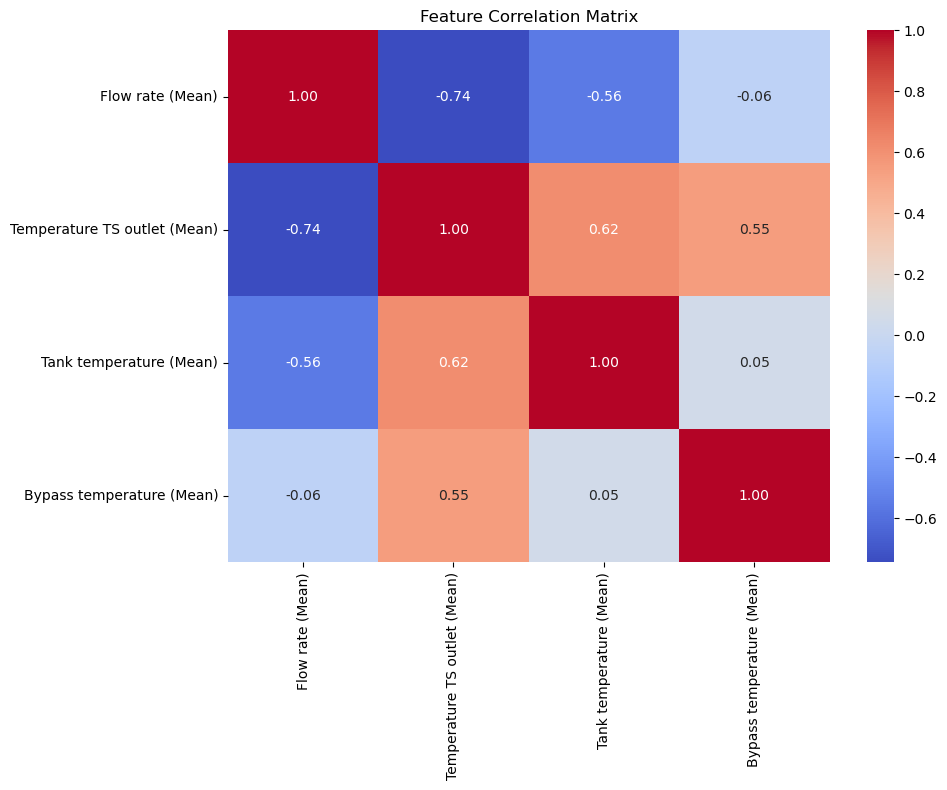

In [11]:
dv.plot_correlation_matrix(X_train_reduced)

In [12]:
y_train.shape

(329747,)

In [13]:
model_reduced = dm.train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

Validation accuracy: 0.968


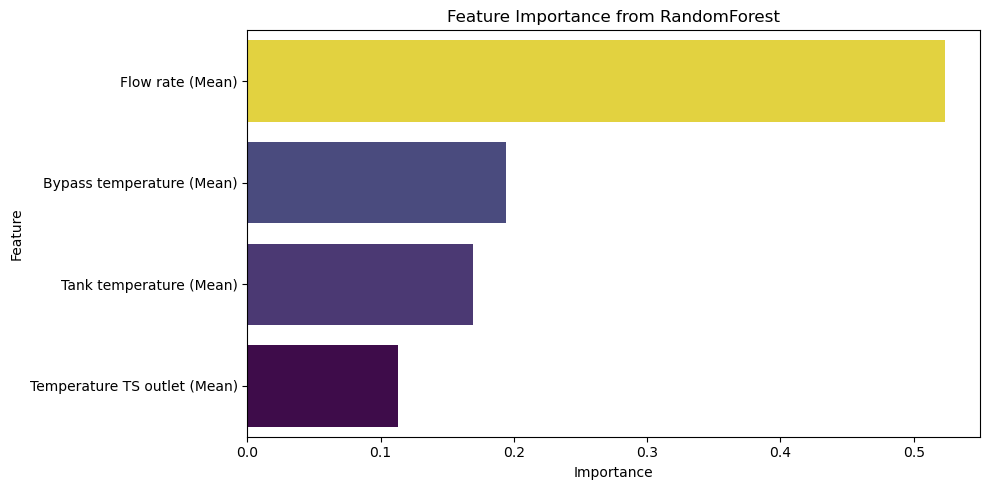

In [14]:
feat_imp_reduced = dv.plot_feature_importance(model_reduced, X_train_reduced)

### Upsampling

In [15]:
#dm.SMOTE_model(X_train_reduced, y_train, X_val_reduced, y_val)

### Downsampling

In [16]:
#dm.undersample_model(X_train_reduced, y_train, X_val_reduced, y_val)

In [17]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 329469 samples
  Class 1.0: 278 samples


### Logreg

In [18]:
X_train_scaled, X_val_scaled, X_test_scaled = dp.scale_features(X_train, X_val, X_test)

logreg = dm.logistic_regression_model(X_train_scaled, y_train, X_val_scaled, y_val)

Validation set results for logistic regression:
              precision    recall  f1-score   support

         0.0      1.000     0.686     0.814      1531
         1.0      0.094     1.000     0.172        50

    accuracy                          0.696      1581
   macro avg      0.547     0.843     0.493      1581
weighted avg      0.971     0.696     0.793      1581



# Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [19]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...
Params: {'n_estimators': 100, 'max_depth': 10} | Validation Accuracy = 0.8140
Params: {'n_estimators': 100, 'max_depth': 20} | Validation Accuracy = 0.8280
Params: {'n_estimators': 200, 'max_depth': 10} | Validation Accuracy = 0.8336
Params: {'n_estimators': 200, 'max_depth': 20} | Validation Accuracy = 0.8014

✅ Best parameters found: {'n_estimators': 200, 'max_depth': 10}
Best validation accuracy: 0.8336
Best Random Forest model with params: {'n_estimators': 200, 'max_depth': 10} achieved validation accuracy: 0.8336

🔍 Tuning Logistic Regression...
Searching over 4 hyperparameter combinations...
Params: {'C': 1.0, 'solver': 'lbfgs'} | Validation Accuracy = 0.9507
Params: {'C': 1.0, 'solver': 'liblinear'} | Validation Accuracy = 0.9785
Params: {'C': 0.5, 'solver': 'lbfgs'} | Validation Accuracy = 0.9855
Params: {'C': 0.5, 'solver': 'liblinear'} | Validation Accuracy = 0.9861

✅ Best parameters found: {'C': 0.5,

## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [20]:
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
dm.evaluate_model_on_test(best_model, X_test, y_test)

Test set results:
              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000      1582

    accuracy                          1.000      1582
   macro avg      1.000     1.000     1.000      1582
weighted avg      1.000     1.000     1.000      1582



## Save best model


In [24]:
dm.save_model(best_model, "../models/best_pipeline.joblib")

Saved model to ../models/best_pipeline.joblib
